# ORFEES dynamic spectrum

This notebook reads ORFEES (Observation Radiofréquence pour l'Étude des Éruptions Solaires)
Stokes I data from the `int_orf*.fts` FITS files and plots the dynamic spectrum.

ORFEES is a solar-dedicated radio spectrograph operating at the Nançay Radio
Astronomy Station, covering roughly **144 MHz - 1004 MHz** in five sub-bands
(B1 - B5). Each sub-band carries its own time array, so the bands are stacked
in frequency and resampled onto a common time grid below.

**Workflow:** load FITS &rarr; stack the five sub-bands &rarr; build a (time, frequency) DataFrame &rarr; downsample to 1 s &rarr; subtract a per-channel median background &rarr; plot.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import LogNorm
import matplotlib as mpl

# Use the precise matplotlib epoch (avoids ~10 us offsets in old matplotlib).
mpl.rcParams['date.epoch'] = '1970-01-01T00:00:00'
try:
    mdates.set_epoch('1970-01-01T00:00:00')
except RuntimeError:
    pass

# Unified plotting style for all dynamic spectra notebooks.
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

from astropy.io import fits
from astropy.time import Time
import astropy.units as u

## Configuration


In [5]:
# Observation date and I/O paths.
mydate = '2025-03-25'

data_dir = '../sample_data/orfees'
outputs  = './outputs'
os.makedirs(outputs, exist_ok=True)

year, month, day = mydate.split('-')

## Helper functions


In [6]:
def subtract_background_median(df):
    """
    Subtract a per-channel median background from a dynamic spectrum.

    The function computes the median along the time axis (axis=0) for each
    frequency channel, then subtracts it from every time sample of that
    channel. This is the standard approach for highlighting transient
    emission against a slowly-varying instrumental/sky background.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with shape (n_times, n_freqs). Index is time, columns
        are frequencies.

    Returns
    -------
    pandas.DataFrame
        Same shape as input with the per-channel median removed.
    """
    bkg = np.nanmedian(df.values, axis=0)
    return df - np.tile(bkg, (df.shape[0], 1))

## Load ORFEES data


In [7]:
files = sorted(glob.glob(f'{data_dir}/int_orf{year}{month}{day}_*.fts'))
print(*files, sep='\n')

orfees = fits.open(files[0])
orfees.info()

../sample_data/orfees/int_orf20250325_053100_0.1.fts
Filename: ../sample_data/orfees/int_orf20250325_053100_0.1.fts
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   ()      
  1  FREQUENCIES    1 BinTableHDU     37   1R x 11C   [1J, 1J, 431E, 1J, 215E, 1J, 164E, 1J, 86E, 1J, 102E]   
  2  SPECTRA       1 BinTableHDU     78   358292R x 15C   [1J, 431E, 431E, 1J, 215E, 215E, 1J, 164E, 164E, 1J, 86E, 86E, 1J, 102E, 102E]   


In [8]:
# Stack the five sub-bands B1-B5 into a single (time, freq) array.
# Each band shares a time grid (TIME_B1 is taken as the reference).
stokes_i = np.hstack([orfees[2].data[f'STOKESI_B{i}'] for i in range(1, 6)])

# Build the absolute time axis: DATE-OBS plus the per-sample offset in ms.
obs_start = orfees[0].header['DATE-OBS']
times = Time(obs_start) + (orfees[2].data['TIME_B1'] / 1000.0) * u.s
freqs = np.hstack([orfees[1].data[f'FREQ_B{i}'] for i in range(1, 6)]) * u.MHz

df_orfees = pd.DataFrame(
    data=stokes_i,
    index=[t.datetime for t in times],
    columns=freqs.value.reshape(-1),
)
df_orfees.index.name = 'Time'
df_orfees.columns.name = 'Frequency (MHz)'

print(f'Shape (time, freq): {df_orfees.shape}')
print(f'Time range: {df_orfees.index[0]} -> {df_orfees.index[-1]}')
print(f'Freq range: {df_orfees.columns.min():.2f} - {df_orfees.columns.max():.2f} MHz')

Shape (time, freq): (358292, 998)
Time range: 2025-03-25 06:56:06.740000 -> 2025-03-25 16:53:15.840000
Freq range: 144.13 - 1004.70 MHz


## Downsample and remove background


In [9]:
# Downsample to 1 s for plotting; ORFEES native cadence is much higher.
df_orfees_1s = df_orfees.resample('1S').mean()

# Per-channel median background subtraction.
df_orfees_nobkg = subtract_background_median(df_orfees_1s)

## Plot the dynamic spectrum


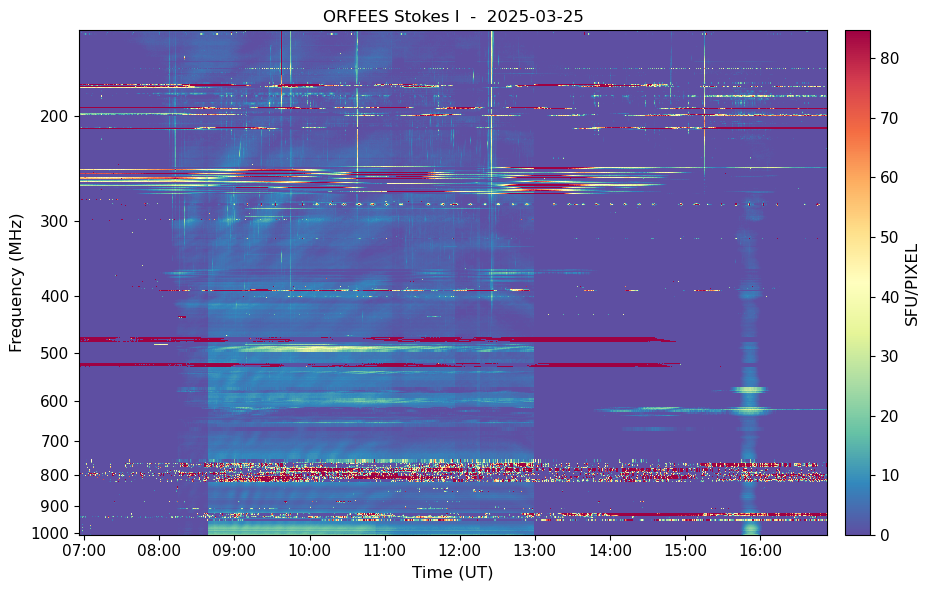

In [10]:
# Choose a time window. Use the full file by default; override as needed.
start_time = df_orfees_nobkg.index[0]
end_time   = df_orfees_nobkg.index[-1]

# Colour scale clipped at the bulk of the data and the burst peak.
vmin = np.nanpercentile(df_orfees_nobkg.values, 50)
vmax = np.nanpercentile(df_orfees_nobkg.values, 97.5)

fig = plt.figure(figsize=(10, 6))
ax  = fig.add_subplot(111)
pc  = ax.pcolormesh(
    df_orfees_nobkg.index,
    df_orfees_nobkg.columns,
    df_orfees_nobkg.T,
    vmin=vmin, vmax=vmax,
    cmap='Spectral_r',
)
fig.colorbar(pc, ax=ax, pad=0.02, label=orfees[2].header.get('BUNIT', 'SFU'))

ax.set_xlabel('Time (UT)')
ax.set_ylabel('Frequency (MHz)')
ax.set_yscale('log')
ax.set_ylim(ax.get_ylim()[::-1])  # high frequency at top (descending)

# Major ticks at the canonical ORFEES decadal points.
yticks = [200, 300, 400, 500, 600, 700, 800, 900, 1000]
ax.set_yticks(yticks)
ax.get_yaxis().set_major_formatter(ticker.FormatStrFormatter('%d'))
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlim(left=pd.Timestamp(start_time), right=pd.Timestamp(end_time))
ax.set_title(f'ORFEES Stokes I  -  {mydate}')

fig.tight_layout()
fig.savefig(f'{outputs}/orfees_dyspec_{mydate}.png', bbox_inches='tight')
plt.show()